# LLM Repair Evaluation

Evaluate LLM-based repair and translation quality.

In [1]:
import os, json, sys, datetime
sys.path.append(os.path.join(os.getcwd(), "..", "src"))
from dotenv import load_dotenv
load_dotenv(override=True)  # project .env wins over any machine-level OPENAI_MODEL
from openai import OpenAI
import sacrebleu
import pandas as pd
from rapidfuzz.distance import Levenshtein
from normalization import strip_context
from retrieve import load_translation_memory, fuzzy_retrieval
from translate import build_translation_messages, call_translation, translate_segment
from repair import build_repair_messages, call_repair


## Preparing the source data

In [2]:
# Importing gold set to list of dictionaries
with open("gold_set.jsonl", "r", encoding="utf-8") as file:
    gold_set = [json.loads(row) for row in file if row.strip()]
    
print(gold_set[1])

{'case_id': 'f02', 'category': 'fuzzy_real', 'query': 'plague ($type)', 'reference': 'zaraza ($type)', 'edit_type': 'addition', 'requires_agreement': 'no', 'flag': 'ok', 'comment': None, 'previous_source': 'plague', 'target_approved': 'zaraza', 'source_file': 'pl_help.po'}


In [3]:
necessary_fields = [
    "case_id",
    "category",
    "edit_type",
    "requires_agreement",
    "query",
    "reference"
]

additional_fields = [
    "target_approved"
]

gold_set_filtered = []

for record in gold_set:
    new_record = {
        field: record.get(field)
        for field in necessary_fields
    }

    if record.get("category") == "edited" or record.get("category") == "fuzzy_real":
        new_record.update({
            field: record.get(field)
            for field in additional_fields
        })

    # Strip the Wesnoth gettext context prefix (e.g. "female^Drake Arbiter")
    # so the model sees clean text; keep the prefix as a separate hint field.
    context, query_norm = strip_context(record.get("query", ""))
    new_record["query_norm"] = query_norm
    new_record["context"] = context

    gold_set_filtered.append(new_record)

print(gold_set_filtered[0])

{'case_id': 'f01', 'category': 'fuzzy_real', 'edit_type': 'reworded', 'requires_agreement': 'no', 'query': 'Pirate Flagship', 'reference': 'Okręt flagowy piratów', 'target_approved': 'Ogniste widmo', 'query_norm': 'Pirate Flagship', 'context': ''}


In [4]:
# Metadata table for all 75 cases (no per-condition outputs here, those live in llm_runs.jsonl)
gold_set_df = pd.DataFrame(gold_set_filtered)
gold_set_df.to_csv('gold_set.csv', index=False, encoding="utf-8")
print(gold_set_df.shape)
gold_set_df.head()

(75, 9)


,case_id,category,edit_type,requires_agreement,query,reference,target_approved,query_norm,context
0,f01,fuzzy_real,reworded,no,Pirate Flagship,Okręt flagowy piratów,Ogniste widmo,Pirate Flagship,
1,f02,fuzzy_real,addition,no,plague ($type),zaraza ($type),zaraza,plague ($type),
2,f03,fuzzy_real,tag/formatting,no,Campaigns and Scenarios,Kampanie i scenariusze,<header>text='Kampanie i Scenariusze'</header>,Campaigns and Scenarios,
3,f04,fuzzy_real,addition,no,<ref>dst='..calendar' text='Calendar'</ref>\n<...,<ref>dst='..calendar' text='Kalendarz'</ref>\n...,<ref>dst='..geography' text='Geografia'</ref>,<ref>dst='..calendar' text='Calendar'</ref>\n<...,
4,f05,fuzzy_real,addition,yes,Time of Day Schedule,Grafik pór dnia,Pora dnia,Time of Day Schedule,


## Setup: model, translation memory, and prototype

In [5]:
client = OpenAI()
model = os.getenv("OPENAI_MODEL", "gpt-4o")
target_language = "Polish"
tm = load_translation_memory("../data/tm/translation_memory.jsonl")

### Prototype: verify one example (case f09) across all three conditions

Working style: check one case end to end, including the printed prompts, before
generalising to a loop over all 75.

In [6]:
# Prototype on a single gender case (f09) across all three conditions before looping.
proto = next(r for r in gold_set_filtered if r["case_id"] == "f09")
print(f"case_id={proto['case_id']}  query_norm={proto['query_norm']!r}  context={proto['context']!r}  reference={proto['reference']!r}")

# Arm 1: scratch
messages_scratch = build_translation_messages(proto["query_norm"], target_language, "baseline_scratch")
output_scratch = call_translation(messages_scratch, model, client)
print("\n--- scratch ---")
print(messages_scratch)
print("output:", output_scratch)

# Arm 2: scratch_context
messages_context = build_translation_messages(proto["query_norm"], target_language, "baseline_context", context=proto["context"])
output_context = call_translation(messages_context, model, client)
print("\n--- scratch_context ---")
print(messages_context)
print("output:", output_context)

# Arm 3: repair (end-to-end retrieval)
proto_score, proto_rec = fuzzy_retrieval(tm, proto["query_norm"], top_n=1)[0]
proto_tm_source = proto_rec["source_norm"]
proto_tm_target = proto_rec["target"]
messages_repair = build_repair_messages(proto["query_norm"], target_language, proto_tm_source, proto_tm_target, "v4_source_changes", context=proto["context"])
output_repair = call_repair(messages_repair, model, client)
print("\n--- repair ---")
print(f"retrieved: score={proto_score}  tm_source={proto_tm_source!r}  tm_target={proto_tm_target!r}")
print(messages_repair)
print("output:", output_repair)

case_id=f09  query_norm='Drake Arbiter'  context='female'  reference='Smocza strażniczka'

--- scratch ---
[{'role': 'system', 'content': 'You are a professional video game translator working from English to Polish.\nProduce the full Polish translation of the NEW source.\nThe output must be a complete, fluent Polish sentence. Never leave any part in English.\nPreserve all placeholders (for example $student_hp), tags, and formatting exactly as they appear.\nOutput only the Polish translation, with no commentary.'}, {'role': 'user', 'content': 'New source (English): Drake Arbiter'}]
output: Drake Arbiter

--- scratch_context ---
[{'role': 'system', 'content': 'You are a professional video game translator working from English to Polish.\nProduce the full Polish translation of the NEW source.\nThe output must be a complete, fluent Polish sentence. Never leave any part in English.\nPreserve all placeholders (for example $student_hp), tags, and formatting exactly as they appear.\nIf a gramma

### Run cache

Keyed by (case_id, condition, prompt_version, model), so re-running this
notebook never re-pays for a call already logged in `llm_runs.jsonl` and never
appends a duplicate row.

In [7]:
path = "llm_runs.jsonl"

def load_cache(path):
    """Load existing runs into a dict keyed by (case_id, condition, prompt_version, model)."""
    cache = {}
    if os.path.exists(path):
        with open(path, "r", encoding="utf-8") as f:
            for line in f:
                if not line.strip():
                    continue
                row = json.loads(line)
                key = (row["case_id"], row["condition"], row["prompt_version"], row["model"])
                cache[key] = row
    return cache

def get_or_generate(key, gen_fn, cache, path):
    """Return the cached row for key, or generate it, log it, and cache it."""
    if key in cache:
        return cache[key]
    row = gen_fn()
    with open(path, "a", encoding="utf-8") as f:
        f.write(json.dumps(row, ensure_ascii=False) + "\n")
    cache[key] = row
    return row

cache = load_cache(path)
runs = []

### Arm 1: scratch (no context hint, no RAG)

In [8]:
condition = "scratch"
prompt_version = "baseline_scratch"

for record in gold_set_filtered:
    case_id = record["case_id"]
    key = (case_id, condition, prompt_version, model)

    def gen_fn(record=record):
        output = translate_segment(record["query_norm"], target_language, prompt_version, model, client)
        return {
            "ts": datetime.datetime.now().isoformat(timespec="seconds"),
            "case_id": case_id,
            "category": record["category"],
            "edit_type": record["edit_type"],
            "requires_agreement": record["requires_agreement"],
            "condition": condition,
            "prompt_version": prompt_version,
            "model": model,
            "output": output,
        }

    runs.append(get_or_generate(key, gen_fn, cache, path))

## Impact of the gettext context prefixes (the `^` strings)

_Historical note: the chrF numbers below are from an earlier gpt-4o-mini,
scratch-only exploration that led to the normalization fix, kept here for
context. The current three-arm comparison on gpt-4o lives in the Metrics and
comparison section further down._

Wesnoth stores a disambiguation context inline in the source, before a caret:
`female^Drake Arbiter`, `race^Merfolk`, `race+female^Horse`. In the first
baseline run these were sent to the model verbatim, so it treated the prefix as
text to translate or markup to keep (`female^Drake Arbiter -> "żeńska^Drake
Arbiter"`, `race^Merfolk -> "rasa^Morscy ludzie"`). Against a clean reference
chrF collapsed to near zero. That was a measurement artifact, not a
translation-quality failure.

Fix: normalization now lives in `src/normalization.py` as the single source of
truth. `strip_context` splits a source on the first caret into (context, text).
The translation memory is normalized at ingest into `source_norm` + `context`,
and here the eval query is stripped the same way before the model call
(`query_norm`), so both arms see clean text. The `^` prefix is kept as a
separate `context` field for later use as a grammatical hint.

Effect on the baseline (chrF by edit_type): the caret artifact is gone (no more
`^` in the outputs) and `term` rose from ~43 to ~46. But the `gender` bucket did
not move (20 -> 20). Inspecting those cases shows why: they are short Wesnoth
unit names like `Drake Arbiter -> "Smocza strażniczka"` where the approved
translation is game-specific terminology a from-scratch model cannot derive (it
echoes `Drake Arbiter` or translates literally to `Drake Zderzacz`), and where
the correct form also depends on grammatical gender (`Smok` vs `Smoczyca`) and
register (`Koń` vs `ogier`).

This is expected, and it is the point of the project: from-scratch translation
cannot reproduce approved terminology, so low baseline scores on exactly these
cases are the "before" that the repair arm is meant to beat. The residual gap is
a mix of terminology, register, and grammatical gender, and most of it is
recovered only by the repair step (which reuses the approved TM target), not by
the `female^`/`male^` hint alone. Pre-normalization numbers are kept above for
reference.

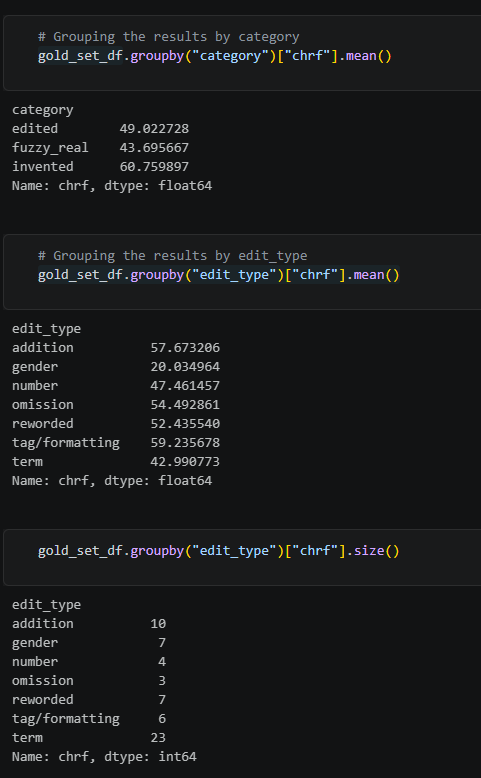

### Arm 2: scratch_context (context hint, no RAG)

In [9]:
condition = "scratch_context"
prompt_version = "baseline_context"

for record in gold_set_filtered:
    case_id = record["case_id"]
    key = (case_id, condition, prompt_version, model)

    def gen_fn(record=record):
        output = translate_segment(record["query_norm"], target_language, prompt_version, model, client, context=record["context"])
        return {
            "ts": datetime.datetime.now().isoformat(timespec="seconds"),
            "case_id": case_id,
            "category": record["category"],
            "edit_type": record["edit_type"],
            "requires_agreement": record["requires_agreement"],
            "condition": condition,
            "prompt_version": prompt_version,
            "model": model,
            "output": output,
        }

    runs.append(get_or_generate(key, gen_fn, cache, path))

### Arm 3: repair (context hint + end-to-end RAG retrieval)

For each query, retrieve the closest translation-memory pair with fuzzy
retrieval (top-1, not the oracle gold pair), then repair it with the same
context hint used by scratch_context.

In [10]:
condition = "repair"
prompt_version = "v4_source_changes"

for record in gold_set_filtered:
    case_id = record["case_id"]
    key = (case_id, condition, prompt_version, model)

    def gen_fn(record=record):
        # End-to-end RAG: retrieve the closest TM pair, then repair with it.
        score, rec = fuzzy_retrieval(tm, record["query_norm"], top_n=1)[0]
        tm_source = rec["source_norm"]   # never rec["source"], may still carry a caret
        tm_target = rec["target"]
        messages = build_repair_messages(record["query_norm"], target_language, tm_source, tm_target, prompt_version, context=record["context"])
        output = call_repair(messages, model, client)
        return {
            "ts": datetime.datetime.now().isoformat(timespec="seconds"),
            "case_id": case_id,
            "category": record["category"],
            "edit_type": record["edit_type"],
            "requires_agreement": record["requires_agreement"],
            "condition": condition,
            "prompt_version": prompt_version,
            "model": model,
            "output": output,
            "retrieval_score": score,
            "tm_source_norm": tm_source,
            "tm_target": tm_target,
        }

    runs.append(get_or_generate(key, gen_fn, cache, path))

# score == 100 means an exact TM match: repair is just a copy, not a real edit.
# Keep the row, retrieval_score lets you filter these out later if needed.
exact_matches = sum(1 for r in runs if r.get("condition") == "repair" and r.get("retrieval_score") == 100)
print(f"repair rows with exact (score=100) retrieval: {exact_matches}")

assert not any("^" in r["output"] for r in runs), "caret leaked into an output"

repair rows with exact (score=100) retrieval: 8


## Metrics and comparison

In [11]:
runs_df = pd.DataFrame(runs)

# Idempotency check: re-running this notebook must never add duplicate rows.
dupe_count = runs_df.duplicated(subset=["case_id", "condition", "prompt_version", "model"]).sum()
assert dupe_count == 0, f"{dupe_count} duplicate (case_id, condition, prompt_version, model) rows in llm_runs.jsonl"

# Bring in "reference" via case_id join (log rows don't carry it, gold_set_df does).
runs_df = runs_df.merge(gold_set_df[["case_id", "reference"]], on="case_id", how="left")

runs_df["chrf"] = [
    sacrebleu.sentence_chrf(output, [reference]).score
    for output, reference in zip(runs_df["output"], runs_df["reference"])
]
runs_df.head()

,ts,case_id,category,edit_type,requires_agreement,condition,prompt_version,model,output,retrieval_score,tm_source_norm,tm_target,reference,chrf
0,2026-09-05T10:54:27,f01,fuzzy_real,reworded,no,scratch,baseline_scratch,gpt-4o,Piracki Okręt Flagowy,NaN,NaN,NaN,Okręt flagowy piratów,40.041167
1,2026-09-05T10:54:27,f02,fuzzy_real,addition,no,scratch,baseline_scratch,gpt-4o,zaraza ($type),NaN,NaN,NaN,zaraza ($type),100.000000
2,2026-09-05T10:54:28,f03,fuzzy_real,tag/formatting,no,scratch,baseline_scratch,gpt-4o,Kampanie i scenariusze,NaN,NaN,NaN,Kampanie i scenariusze,100.000000
3,2026-09-05T10:54:29,f04,fuzzy_real,addition,no,scratch,baseline_scratch,gpt-4o,<ref>dst='..calendar' text='Kalendarz'</ref>\n...,NaN,NaN,NaN,<ref>dst='..calendar' text='Kalendarz'</ref>\n...,100.000000
4,2026-09-05T10:54:29,f05,fuzzy_real,addition,yes,scratch,baseline_scratch,gpt-4o,Harmonogram Czasu Dnia,NaN,NaN,NaN,Grafik pór dnia,12.020922


In [12]:
# Preservation: distance between the repair output and the approved TM target it started from.
# Only meaningful for the repair arm, which is the only one with a tm_target.
is_repair = runs_df["condition"] == "repair"
runs_df["preservation"] = float("nan")
runs_df.loc[is_repair, "preservation"] = [
    Levenshtein.normalized_distance(output, tm_target)
    for output, tm_target in zip(runs_df.loc[is_repair, "output"], runs_df.loc[is_repair, "tm_target"])
]

A GOOD repair has LOW preservation distance to the retrieved approved target
(it kept the human wording) AND high chrF against the new reference (it still
got the new source right). scratch and scratch_context have no TM target, so
preservation is N/A there.

In [13]:
result_columns = [
    "case_id", "category", "edit_type", "requires_agreement",
    "condition", "prompt_version", "model", "output",
    "chrf", "preservation", "retrieval_score",
]
results_df = runs_df.reindex(columns=result_columns)
results_df.to_csv("llm_eval_results.csv", index=False, encoding="utf-8")
results_df.head()

,case_id,category,edit_type,requires_agreement,condition,prompt_version,model,output,chrf,preservation,retrieval_score
0,f01,fuzzy_real,reworded,no,scratch,baseline_scratch,gpt-4o,Piracki Okręt Flagowy,40.041167,NaN,NaN
1,f02,fuzzy_real,addition,no,scratch,baseline_scratch,gpt-4o,zaraza ($type),100.000000,NaN,NaN
2,f03,fuzzy_real,tag/formatting,no,scratch,baseline_scratch,gpt-4o,Kampanie i scenariusze,100.000000,NaN,NaN
3,f04,fuzzy_real,addition,no,scratch,baseline_scratch,gpt-4o,<ref>dst='..calendar' text='Kalendarz'</ref>\n...,100.000000,NaN,NaN
4,f05,fuzzy_real,addition,yes,scratch,baseline_scratch,gpt-4o,Harmonogram Czasu Dnia,12.020922,NaN,NaN


Report by bucket, not just overall: the context hint only changes the prompt
for cases where `context` is non-empty (~9/75 cases), so overall chrF averages
barely move. The signal lives in the edit_type and requires_agreement buckets
below.

In [14]:
# chrF mean by condition (overall) -> the 3-rung headline
results_df.groupby("condition")["chrf"].mean()

condition
repair             76.699392
scratch            54.688016
scratch_context    58.509742
Name: chrf, dtype: float64

In [15]:
# chrF mean by (condition, edit_type) -> focus on gender and term
results_df.groupby(["condition", "edit_type"])["chrf"].mean()

condition        edit_type     
repair           addition          75.708944
                 gender            92.261983
                 number            86.545412
                 omission          86.003821
                 reworded          76.307382
                 tag/formatting    60.758658
                 term              82.966652
scratch          addition          64.194235
                 gender            18.137685
                 number            49.777925
                 omission          64.978294
                 reworded          52.841337
                 tag/formatting    68.431015
                 term              52.451766
scratch_context  addition          63.937187
                 gender            39.503453
                 number            49.777925
                 omission          64.223727
                 reworded          53.279395
                 tag/formatting    70.685262
                 term              57.691946
Name: chrf, dtype: floa

In [16]:
# chrF mean by (condition, requires_agreement) -> the agreement subset
results_df.groupby(["condition", "requires_agreement"])["chrf"].mean()

condition        requires_agreement
repair           no                    77.845411
                 yes                   82.787768
scratch          no                    63.924792
                 yes                   40.281043
scratch_context  no                    68.349245
                 yes                   45.270152
Name: chrf, dtype: float64

In [17]:
# chrF mean by (condition, category) -> so invented (weak matches) does not
# contaminate the fuzzy_real/edited story
results_df.groupby(["condition", "category"])["chrf"].mean()

condition        category  
repair           edited        85.928561
                 fuzzy_real    74.539873
                 invented      62.560091
scratch          edited        55.785903
                 fuzzy_real    49.208057
                 invented      63.452159
scratch_context  edited        56.004156
                 fuzzy_real    58.384545
                 invented      63.771308
Name: chrf, dtype: float64

In [18]:
# preservation mean by edit_type, repair arm only
results_df[results_df["condition"] == "repair"].groupby("edit_type")["preservation"].mean()

edit_type
addition          0.560520
gender            0.136020
number            0.055019
omission          0.521375
reworded          0.280651
tag/formatting    0.695908
term              0.407668
Name: preservation, dtype: float64

In [19]:
# The three deltas
means = results_df.groupby("condition")["chrf"].mean()
deltas = pd.Series({
    "scratch -> scratch_context (context hint alone)": means["scratch_context"] - means["scratch"],
    "scratch_context -> repair (RAG, end-to-end)": means["repair"] - means["scratch_context"],
    "scratch -> repair (full system)": means["repair"] - means["scratch"],
})
deltas

scratch -> scratch_context (context hint alone)     3.821726
scratch_context -> repair (RAG, end-to-end)        18.189650
scratch -> repair (full system)                    22.011376
dtype: float64

Note on the RAG delta: because the repair arm here is end-to-end (retrieve
then repair), the `scratch_context -> repair` delta contains retrieval
quality as well as the LLM repair step, not the repair prompting alone. A weak
fuzzy match can drag this delta down even when the repair prompt itself is
sound. `retrieval_score` is logged per repair row so this can be separated out
later (e.g. by filtering on match quality).

## Reading these results (plain-language guide for reviewers)

This section explains what the numbers mean without assuming any knowledge of
translation or of Polish. Every Polish example below is given with a literal
English gloss, so the mechanism is visible even if you do not read Polish.

**The problem in one paragraph.** A *translation memory* (TM) is a database of
sentences a human translator already translated and approved: an English source
paired with its approved Polish translation. When a new or slightly edited
English string comes in, it is often very close to something already in the TM
(a *fuzzy match*). The usual machine-translation habit is to translate the new
string from scratch, which tends to rewrite wording a human already approved and
to miss game-specific terminology. Our system instead retrieves the closest
approved pair and asks the model to *edit only what the change requires*, keeping
the rest of the human translation intact. This is the "edit, not rewrite" idea,
also called fuzzy-match repair or automatic post-editing.

**The three conditions (a ladder).** Each rung adds exactly one ingredient, so
any change in score can be attributed to that one ingredient:

- `scratch`: translate the new English string blind, with no memory and no hint.
- `scratch_context`: same, plus a small grammatical hint taken from the source
  (for example, that a unit name should take the feminine form).
- `repair`: retrieve the closest approved TM pair and edit it, using the same hint.

**The two metrics.**

- **chrF** (0 to 100, higher is better) measures character-level similarity
  between the model output and a human reference translation. It is
  language-independent, so you do not need to read Polish to compare scores.
- **Preservation** (0 to 1, lower means more preserved) measures how much of the
  *approved* human translation the model kept. It is the normalized edit distance
  between the output and the approved TM target. The goal of repair is the
  combination of high chrF (the new translation is correct) and low preservation
  distance (it reused the approved human wording instead of rewriting it).

In [ ]:
# Self-contained reviewer summary: re-reads the run log and the gold set so the
# tables below always match the committed results.
import json
import sacrebleu
import pandas as pd
from rapidfuzz.distance import Levenshtein

_runs = [json.loads(l) for l in open("llm_runs.jsonl", encoding="utf-8") if l.strip()]
_gold = {r["case_id"]: r for r in
         (json.loads(l) for l in open("gold_set.jsonl", encoding="utf-8") if l.strip())}

for r in _runs:
    r["chrf"] = sacrebleu.sentence_chrf(r["output"], [_gold[r["case_id"]]["reference"]]).score
    if r["condition"] == "repair":
        r["preservation"] = Levenshtein.normalized_distance(r["output"], r.get("tm_target", ""))

by_case = {}
for r in _runs:
    by_case.setdefault(r["case_id"], {})[r["condition"]] = r

conds = ["scratch", "scratch_context", "repair"]

def _mean(ids, cond):
    xs = [by_case[c][cond]["chrf"] for c in ids]
    return round(sum(xs) / len(xs), 1) if xs else float("nan")

# 1) Overall ladder
overall = pd.Series({c: _mean(set(by_case), c) for c in conds}, name="chrF")
print("Overall chrF by condition (the ladder):")
print(overall.to_string(), "\n")

# 2) Split by retrieval quality. "Near-perfect match" means the memory contained
#    an almost identical source (similarity score >= 99).
exact_ids = {cid for cid, d in by_case.items()
             if d["repair"].get("retrieval_score", 0) >= 99}
rest_ids = set(by_case) - exact_ids
split = pd.DataFrame(
    {c: [_mean(exact_ids, c), _mean(rest_ids, c)] for c in conds},
    index=[f"near-perfect retrieval (n={len(exact_ids)})",
           f"weaker / no match (n={len(rest_ids)})"],
)
print("chrF by retrieval quality:")
print(split.to_string(), "\n")

# 3) Preservation on the repair arm, by category (0 = approved wording kept verbatim)
pres = {}
for cat in ["edited", "fuzzy_real", "invented"]:
    xs = [by_case[c]["repair"]["preservation"] for c in by_case
          if _gold[c]["category"] == cat]
    pres[cat] = round(sum(xs) / len(xs), 3)
print("Repair preservation distance by category (lower = more human wording kept):")
print(pd.Series(pres).to_string())

### What the ladder shows

Overall chrF climbs at every rung: from-scratch translation is weakest, adding
the grammatical hint helps a little, and retrieving plus editing the approved
translation helps a lot. The clearest single story is grammatical **gender**,
where the gain is dramatic.

Polish marks grammatical gender on nouns and adjectives through word endings, so
the masculine and feminine forms of the same title are spelled differently. The
correct form cannot be produced from the English name alone, because the
game-specific term itself has to be known. Example (case f09):

- New English source: `Drake Arbiter`, marked as needing the **feminine** form.
- Correct Polish reference: `Smocza strażniczka` (literally "she-dragon
  guardian", feminine).
- `scratch`: `Drake Arbiter`. The model did not know the term and left it in
  English. chrF 6.
- `scratch_context`: `Drakoniczna Arbiterka`. With the hint it attempted a
  feminine form but invented the wrong term. chrF 19.
- `repair`: `Smocza strażniczka`. It retrieved the approved masculine term
  `Smoczy strażnik` ("he-dragon guardian", masculine) and changed only the
  gendered endings. chrF 100.

The mechanism is visible without Polish: Smocz**y** strażni**k** (masculine)
becomes Smocz**a** strażni**czka** (feminine). Only the endings change and the
approved term is reused. This is exactly "edit, not rewrite".

### Where repair helps most: the hardest cases, not the easiest

It is tempting to assume that when the memory contains a near-perfect match the
task becomes trivial, so repair gets an unfair advantage. The data shows the
opposite. On the near-perfect-retrieval cases, from-scratch translation is almost
helpless while repair is nearly perfect (see the "chrF by retrieval quality"
table above: scratch scores around the low twenties, repair near ninety).

The reason is that these cases are short, game-specific unit names such as
`Drake Clasher` or `Armageddon Drake`. A from-scratch model either leaves them in
English or invents a literal translation, because the approved term exists only in
the memory. Repair reuses that approved term and applies the required grammatical
change, which is exactly what a human localizer would do. Preservation confirms
this is real editing rather than copying: on these cases the output still differs
from the approved target by roughly a fifth (the gender change), so it is not a
verbatim paste.

These cases therefore belong in the main result. They are reported as a separate
row only for transparency, not because they should be excluded.

### Where repair hurts, and the fix it points to

Repair is not universally better. It depends on the retrieved example actually
being relevant. The clearest failure is case f19:

- New English source: `Order and Number of Strikes`, correct Polish
  `Kolejność i liczba ciosów` (literally "order and number of blows").
- The memory had no close match, so retrieval returned an unrelated interface
  label at only 50/100 similarity: `Shroud and Fog of War` ->
  `Całun i Mgła wojny`.
- Anchored to that irrelevant, title-cased example, repair rewrote a perfectly
  good draft into `Porządek i Liczba uderzeń`, changing the wording and copying
  the title-case style. chrF fell from 68 (scratch) to 14 (repair).

This single case is what pulls the `tag/formatting` bucket below scratch. Remove
it and repair is level with or slightly ahead of scratch there too. The lesson is
a concrete product improvement: apply repair only when retrieval similarity is
above a threshold (for example 60), and fall back to from-scratch translation
below it. That removes this failure mode while keeping every gain shown above.

### Two footnotes on the data

**The `invented` category has no edit type.** The 15 `invented` cases are
brand-new strings with no matching entry in the memory, so there is no "type of
edit" to label, and they appear under an empty edit-type group. This is by
design, not a gap in the gold set. They exist to show what happens when the
memory genuinely cannot help: retrieval is weak and repair gives no benefit,
which is the expected and honest result.

**The approved translation is sometimes itself debatable.** In case e04,
`Dune Raider`, the memory's approved term is `Wydmowy łupieżca` ("dune
plunderer") while the reviewer reference is `Wydmowy jeździec` ("dune rider").
Repair faithfully reproduced the approved memory term (preservation 0), which
scores low against this particular reference (chrF 39). This is worth knowing:
repair optimizes for consistency with the approved memory, which is usually what
a localization team wants, even when a fresh reference would word it differently.

### Choosing a retrieval-quality threshold

The section above showed that repair only helps when the retrieved match is
relevant, and can hurt when it is not. That suggests a simple, defensible product
rule: only repair when the retrieval similarity is high enough, and otherwise fall
back to a from-scratch translation (with the context hint). The question is where
to put the cutoff. Rather than guess, we read it off our own results.

The cell below groups the 75 repair cases by their fuzzy retrieval score and, for
each bin, reports the average chrF gain of repair over the from-scratch fallback
(`scratch_context`). It then sweeps candidate thresholds T and, for each, measures
the overall chrF of the policy "use repair if score >= T, else use
scratch_context".

In [ ]:
# Data-driven retrieval-quality threshold (self-contained: re-reads the logs).
import json
import sacrebleu

_runs = [json.loads(l) for l in open("llm_runs.jsonl", encoding="utf-8") if l.strip()]
_gold = {r["case_id"]: r for r in
         (json.loads(l) for l in open("gold_set.jsonl", encoding="utf-8") if l.strip())}
for r in _runs:
    r["chrf"] = sacrebleu.sentence_chrf(r["output"], [_gold[r["case_id"]]["reference"]]).score

_bc = {}
for r in _runs:
    _bc.setdefault(r["case_id"], {})[r["condition"]] = r

# Per-case: fuzzy retrieval score, and repair minus the scratch_context fallback.
pairs = []
for cid, d in _bc.items():
    s = d["repair"].get("retrieval_score", 0.0)
    pairs.append((s, d["repair"]["chrf"] - d["scratch_context"]["chrf"]))

print("Mean chrF gain of repair over scratch_context, by fuzzy score bin:")
for lo, hi in [(0, 40), (40, 55), (55, 70), (70, 85), (85, 99), (99, 101)]:
    b = [g for s, g in pairs if lo <= s < hi]
    if b:
        print(f"  score [{lo:3},{hi:3})  n={len(b):2}  mean gain = {sum(b)/len(b):+6.1f}")

def policy_chrf(T):
    vals = [(d["repair"]["chrf"] if d["repair"].get("retrieval_score", 0) >= T
             else d["scratch_context"]["chrf"]) for d in _bc.values()]
    return sum(vals) / len(vals)

print("\nPolicy sweep (repair if score >= T, else scratch_context):")
for T in [0, 40, 50, 55, 60, 65, 70, 80, 101]:
    tag = "  <- always repair" if T == 0 else ("  <- always scratch" if T == 101 else "")
    print(f"  T = {T:3}   overall chrF = {policy_chrf(T):.1f}{tag}")

**Conclusion.** Repair hurts on average below a fuzzy score of about 55 (the
matches there are unrelated, for example case f19) and helps increasingly above
it. The policy sweep peaks at **T = 55** (overall chrF about 77.7, versus 76.7 for
always repairing). So the application uses **55** as its retrieval-quality gate:
if the closest approved translation scores below 55, the app translates from
scratch instead of repairing.

Two honest caveats. First, the average improvement over always-repairing is small
(about +1 chrF); the real value of the threshold is robustness, because it removes
the worst-case failures (case f19 alone swings by about 54 points) rather than
lifting the mean by much. Second, 55 is tuned to this translation memory and to
the rapidfuzz similarity scale (0 to 100); it is a fitted constant, not a
universal one, and would be re-tuned for a different memory.